# Decision Tree Classifier

## Imports

In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## 1. Data Preparation

- The dataset used in this notebook is the Breast Cancer Wisconsin (Diagnostic) Dataset from scikit-learn. 
- It contains 30 features, and the target variable indicates whether a tumor is malignant (cancerous) or benign (non-cancerous). 
- Malignant tumors are labeled as 0, and benign tumors are labeled as 1.

### 1.1 Load and Split Data

In [168]:
data = load_breast_cancer()
X = data.data
t = data.target

# split dataset into 70% training, 30% validation + test
X_train, X_temp, t_train, t_temp = train_test_split(X, t, test_size=0.3, random_state=42, stratify=t)
    
# split the remaining into 15% validation and 15% test sets
X_val, X_test, t_val, t_test = train_test_split(X_temp, t_temp, test_size=0.5, random_state=42, stratify=t_temp)

#### Verify Split Sizes

In [169]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 398 samples
Validation set size: 85 samples
Test set size: 86 samples


Since we're going to retrain again on the combined training and validation set after hyperparameter tuning, they are merged back together.

In [170]:
X_main = np.concatenate([X_train, X_val])
t_main = np.concatenate([t_train, t_val])

In [171]:
print(f"Main set size: {X_main.shape[0]} samples")

Main set size: 483 samples


## 2. Decision Tree Class Implementation

### 2.1 Node Class

Nodes are like containers that hold information about each split. It has the feature to be split on, the threshold value for the split, left and right child nodes which result from the split, and a value that is only used for leaf nodes to represent the class label.

The * in the constructor indicates that any parameters after it must be specified with their names. Generally, the value parameter is not provided, it's only for the leaf nodes.

In [172]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature      # index of feature to split on
        self.threshold = threshold  # value to split at
        self.left = left            # left child node
        self.right = right          # right child node
        self.value = value          # only for leaf nodes, class label
        
    def is_leaf_node(self):
        return self.value is not None

### 2.2 Decision Tree Class

The class is initialized with stopping criteria parameters such as minimum samples required to split a node, maximum depth of the tree.

The `fit()` method starts the main recursive `_grow_tree()` function that builds the tree. It recursively splits the data based on the best feature and threshold until stopping criteria are met.

The `predict()` method simply traverses the tree until it reaches a leaf node for each sample and returns the predicted class labels

**Stopping Criteria:**
- Maximum tree depth (max_depth). 
- Minimum number of samples required to split a node (min_samples_split). 
- Nodes where all samples belong to the same class. 

**Feature Importance**
- On each split, the information gain is calculated and returned along with the best feature index and threshold.
- This IG is then multiplied by the number of samples in the node to get the contribution of that split to the overall feature importance.
- At the end, each number will represent the rank of its importance.

In [173]:
class DecisionTree:
    def __init__(self, minimum_samples_split=2, max_depth=10):
        self.minimum_samples_split = minimum_samples_split
        self.max_depth = max_depth
        self.n_features = None
        self.root = None
        self.feature_importances = None
        
    def fit(self, X, y):
        self.n_features = X.shape[1]
        self.feature_importances = np.zeros(self.n_features)
        self.root = self._grow_tree(X, y)
        
    def predict(self, X):
        results = np.array([self._traverse(x, self.root) for x in X])
        return results
        
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))
        
        # stopping criteria
        if depth >= self.max_depth or n_labels == 1 or n_samples < self.minimum_samples_split:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # find the best split
        feat_indices = self._get_feature_indices(n_feats)
        best_feature_index, best_threshold, information_gain = self._best_split(X, y, feat_indices)
        
        # update feature importance: gain * number of samples in the current node
        self.feature_importances[best_feature_index] += (information_gain * n_samples)
        
        # stopping criteria if no split is found
        if best_feature_index is None:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # split to left/right subtrees with the given best split
        left_indices, right_indices = self._split(X[:, best_feature_index], best_threshold)
        
        left_subtree = self._grow_tree(X[left_indices, :], y[left_indices], depth + 1)
        right_subtree = self._grow_tree(X[right_indices, :], y[right_indices], depth + 1)
        
        return Node(feature=best_feature_index, threshold=best_threshold, left=left_subtree, right=right_subtree)
    
    # returns all feature indices (to be overriden for RandomTree)
    def _get_feature_indices(self, n_feats):
        return range(n_feats)
    
    def _best_split(self, X, y, feat_indices):
        best_gain = -1
        split_index = None
        split_threshold = None

        # for all features to be checked (access them with their indices)
        for feat_index in feat_indices:
            X_column = X[:, feat_index]
            # get all unique values to use as potential thresholds
            thresholds = np.unique(X_column)

            # loop through all possible thresholds for this feature
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)

                if gain > best_gain:
                    best_gain = gain
                    split_index = feat_index
                    split_threshold = threshold

        return split_index, split_threshold, best_gain
    
    def _traverse(self, x, node):
        if node.is_leaf_node():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse(x, node.left)
        else:
            return self._traverse(x, node.right)
        
    
    def _split(self, X_column, split_thresh):
        left_indices = np.argwhere(X_column <= split_thresh).flatten()
        right_indices = np.argwhere(X_column > split_thresh).flatten()
        return left_indices, right_indices

    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value
        
    # Mathematical functions
    
    def _information_gain(self, y, X_column, threshold):
        parent_entropy = self._entropy(y)

        left_indices, right_indices = self._split(X_column, threshold)

        # No split occurred, no information gain
        if len(left_indices) == 0 or len(right_indices) == 0:
            return 0
        
        n = len(y)
        n_left = len(left_indices)
        n_right = len(right_indices)
        e_left = self._entropy(y[left_indices])
        e_right = self._entropy(y[right_indices])
        
        # Weighted average of the child entropy
        child_entropy = (n_left / n) * e_left + (n_right / n) * e_right

        information_gain = parent_entropy - child_entropy
        return information_gain
    
    def _entropy(self, y):
        # bincount returns a histogram of counts of each unique value in y
        histogram = np.bincount(y)
        
        # divide by total number to get probabilities
        ps = histogram / len(y)
    
        return -np.sum([p * np.log(p) for p in ps if p > 0])

**Note:** We don't use log of base 2 for entropy calculation here. It works fine since it's only used for comparison purposes.

Other notes:

- `argwhere()` returns indices where the condition is True, flatten is used to convert lists of lists into a single list.

## 3. Hyperparameter Tuning and Analysis

Explore max_depth ∈ {2, 4, 6, 8, 10} and min_samples_split ∈ {2, 5, 10}. 

### 3.1 Tuning

In [174]:
max_depths = [2, 4, 6, 8, 10]
min_samples_splits = [2, 5, 10]

Test all 5 x 3 = 15 combinations on the validation set and check the accuracy of each combination. The combination with the highest accuracy will be selected for the final model.

If the same accuracy is achieved by multiple combinations, choose the one with the large st max_depth and smallest min_samples_split. It's been commented out for now.

All data is stored in a dictionary which will be converted to a DataFrame for better visualization.

In [175]:
results = []

best_min_samples_split = None
best_max_depth = None
best_accuracy = 0
best_index = None
index = -1 # to start from 0

for max_depth in max_depths:
    for min_samples_split in min_samples_splits:
        index += 1
        model = DecisionTree(minimum_samples_split=min_samples_split, max_depth=max_depth)
        model.fit(X_train, t_train)
        
        # Training accuracy
        t_train_pred = model.predict(X_train)
        train_accuracy = np.sum(t_train_pred == t_train) / len(t_train) * 100
        
        # Validation accuracy
        t_val_pred = model.predict(X_val)
        validation_accuracy = np.sum(t_val_pred == t_val) / len(t_val) * 100
        
        results.append({
            'max_depth': max_depth,
            'min_samples_split': min_samples_split,
            'train_accuracy': train_accuracy,
            'validation_accuracy': validation_accuracy
        })
        
        if validation_accuracy > best_accuracy:
            best_accuracy = validation_accuracy
            best_max_depth = max_depth
            best_min_samples_split = min_samples_split
            best_index = index
        
df_results = pd.DataFrame(results)

print("Best Hyperparameters:")
print(df_results.iloc[best_index])

best_model = DecisionTree(minimum_samples_split=best_min_samples_split, max_depth=best_max_depth)

df_results.columns = ['Max Depth', 'Min Samples Split', 'Train Accuracy (%)', 'Validation Accuracy (%)']

df_results

Best Hyperparameters:
max_depth               4.000000
min_samples_split       2.000000
train_accuracy         99.246231
validation_accuracy    97.647059
Name: 3, dtype: float64


,Max Depth,Min Samples Split,Train Accuracy (%),Validation Accuracy (%)
0,2,2,95.226131,91.764706
1,2,5,95.226131,91.764706
2,2,10,95.226131,91.764706
3,4,2,99.246231,97.647059
4,4,5,99.246231,97.647059
5,4,10,98.994975,97.647059
6,6,2,99.497487,95.294118
7,6,5,99.497487,95.294118
8,6,10,99.246231,95.294118
9,8,2,100.000000,97.647059


## 4. Final Model Evaluation

### 4.1 Max Depth Accuracy on Training and Validation Set

With fixed min_samples_split, the effect of changing max_depth values on the accuracy on both training and validation set is analyzed.

    Max Depth  Min Samples Split  Train Accuracy (%)  Validation Accuracy (%)
0           2                  2           95.226131                91.764706
3           4                  2           99.246231                97.647059
6           6                  2           99.497487                95.294118
9           8                  2          100.000000                97.647059
12         10                  2          100.000000                97.647059

    Max Depth  Min Samples Split  Train Accuracy (%)  Validation Accuracy (%)
1           2                  5           95.226131                91.764706
4           4                  5           99.246231                97.647059
7           6                  5           99.497487                95.294118
10          8                  5           99.497487                95.294118
13         10                  5           99.497487                95.294118

    Max Depth  Min Samples Split  Train Accuracy (%)  Validati

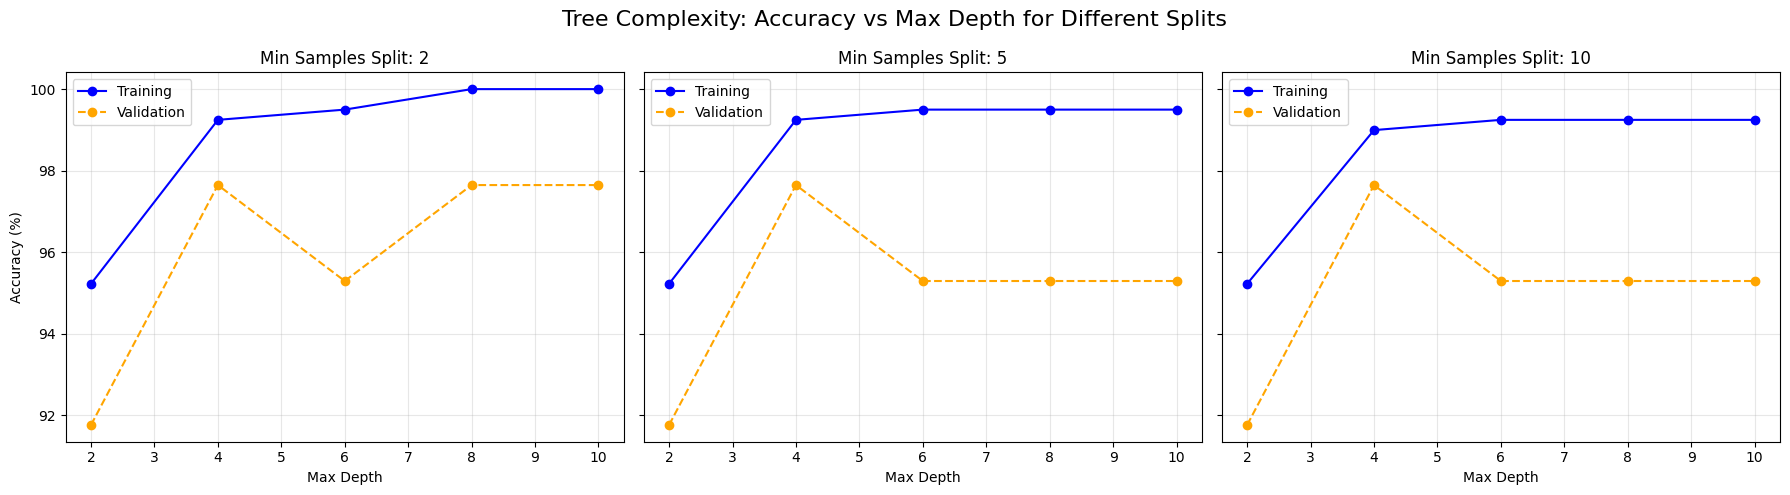

In [176]:
df_filtered = df_results.copy()
df_list = []

for min_samples_split in min_samples_splits:
    df_subset = df_filtered[df_filtered['Min Samples Split'] == min_samples_split]
    df_subset = df_subset.sort_values(by='Max Depth')
    df_list.append(df_subset)
    
# Table Summary
for df in df_list:
    print(df)
    print()
    
# Plotting
n_groups = len(df_list)
fig, axes = plt.subplots(1, n_groups, figsize=(6 * n_groups, 5), sharey=True)

for i, df in enumerate(df_list):
    ax = axes[i]
    
    current_split = df['Min Samples Split'].iloc[0]
    
    # plot training accuracy as blue solid line 
    ax.plot(df['Max Depth'], df['Train Accuracy (%)'], label='Training', marker='o', linestyle='-', color='blue')
    
    # plot Validation Accuracy as dashed orange line
    ax.plot(df['Max Depth'], df['Validation Accuracy (%)'], label='Validation', marker='o', linestyle='--', color='orange')
    
    # Formatting
    ax.set_title(f'Min Samples Split: {current_split}')
    ax.set_xlabel('Max Depth')
    
    if i == 0:
        ax.set_ylabel('Accuracy (%)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Tree Complexity: Accuracy vs Max Depth for Different Splits', fontsize=16)
plt.tight_layout()
plt.show()

This shows that as the tree depth increases, the training accuracy improves while the validation accuracy decreases, which is a sign of overfitting on the training data.

### 4.2 Test Set Evaluation

With the best given hyperparameters, retrain the decision tree on the combined training and validation set, and evaluate its performance on the test set.

In [177]:
best_model.fit(X_main, t_main)
t_test_pred = best_model.predict(X_test)
accuracy = np.sum(t_test_pred == t_test) / len(t_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 88.37%


Test accuracy is lower than validation accuracy is justified as the model might have overfitted to the training and validation data, while picking the right hyperparameters for the 15% validation set.

### 4.3 Performance Metrics

Final Test Set Performance (Benign Class):
Accuracy:  0.8837
Precision: 0.8929
Recall:    0.9259
F1 Score:  0.9091


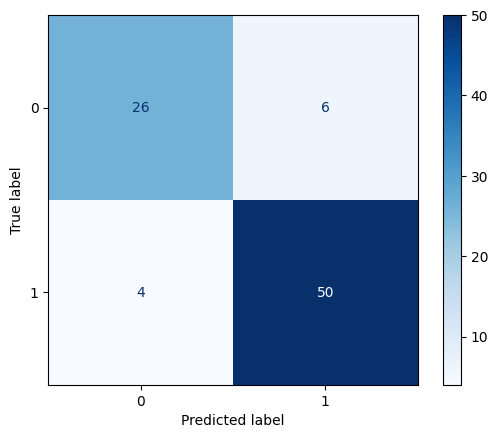

In [178]:
accuracy_dt = accuracy_score(t_test, t_test_pred)
precision_dt = precision_score(t_test, t_test_pred)
recall_dt = recall_score(t_test, t_test_pred)
f1_dt = f1_score(t_test, t_test_pred)
conf_matrix_dt = confusion_matrix(t_test, t_test_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_dt)

disp_dt.plot(cmap=plt.cm.Blues)

print("Final Test Set Performance (Benign Class):")
print(f"Accuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1 Score:  {f1_dt:.4f}")

In [179]:
# for each class
print(classification_report(t_test, t_test_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.87      0.81      0.84        32
      benign       0.89      0.93      0.91        54

    accuracy                           0.88        86
   macro avg       0.88      0.87      0.87        86
weighted avg       0.88      0.88      0.88        86



In [180]:
# rank and display feature importance
feature_names = data.feature_names
importances = best_model.feature_importances
indices = np.argsort(importances)[::-1] # descending order

for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

1. worst perimeter: 199.8480
2. worst concave points: 52.8015
3. worst radius: 17.5579
4. mean texture: 11.5192
5. worst texture: 9.2394
6. worst area: 5.9258
7. area error: 4.2540
8. mean radius: 3.8191
9. worst smoothness: 0.0000
10. worst symmetry: 0.0000


# Random Forest Classifier

### 1. Class Implementation

Since the random forest uses multiple decision trees that work on random subsets of features, a new class is created that inherits from the DecisionTree class. It has an additional parameter max_features that specifies how many random features to consider at each split.

#### Random Tree Class

In [181]:
class RandomTree(DecisionTree):
    def __init__(self, minimum_samples_split=2, max_depth=10, max_features=None):
        super().__init__(minimum_samples_split, max_depth)
        self.max_features = max_features

    def _get_feature_indices(self, n_feats):
        if self.max_features is not None and self.max_features < n_feats:
            return np.random.choice(n_feats, self.max_features, replace=False)
        else:
            return range(n_feats)

#### Random Forest Class

In [182]:
class RandomForest:
    def __init__(self, n_trees=5, minimum_samples_split=2, max_depth=10, max_features=None):
        self.n_trees = n_trees
        self.minimum_samples_split = minimum_samples_split
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []
        
    def fit(self, X, y):
        self.trees = []
        
        n_samples= X.shape[0]
        
        # train n_trees random trees
        for _ in range(self.n_trees):
            # bootstrap sampling
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X[idxs], y[idxs]
            
            tree = RandomTree(minimum_samples_split=self.minimum_samples_split, max_depth=self.max_depth, max_features=self.max_features)
            
            # fit on original x and y
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            
    def predict(self, X):
        # get predictions from each tree
        tree_preds = []
        for tree in self.trees:
            tree_pred = tree.predict(X)  # returns array of predictions
            tree_preds.append(tree_pred) # create a list of arrays of predictions
        
        # majority vote
        tree_preds = np.array(tree_preds)
        tree_preds = np.swapaxes(tree_preds, 0, 1) # transpose so that each row corresponds to predictions for a sample
        results = []
        for tree_pred in tree_preds:
            most_common = Counter(tree_pred).most_common(1)[0][0] # get the most common prediction for each row (sample)
            results.append(most_common)                           # final prediction for that one sample
            
        return np.array(results)

### 2. Hyperparameter Tuning

- Use the `best_max_depth` and `best_min_samples_split` values found in Part B for all trees. 
- Test `n_trees` ∈ {5, 10, 30, 50} and `max_features` ∈ {⌊√d⌋, ⌊d/2⌋}, where d is the number of features.

In [183]:
n_trees_options = [5, 10, 30, 50]
number_of_features = X_train.shape[1] 
max_features_options = [int(np.sqrt(number_of_features)), int(number_of_features / 2)]

Test all 4 x 2 = 8 combinations on the validation set and check the accuracy of each combination. 

In [184]:
results = []

best_n_trees = None
best_max_features = None

best_accuracy = 0
best_index = None
index = -1 # to start from 0

for n_trees in n_trees_options:
    for max_features in max_features_options:
        # print(f"Evaluating Random Forest with n_trees={n_trees}, max_features={max_features}")
        index += 1
        model = RandomForest(n_trees=n_trees, minimum_samples_split=best_min_samples_split, max_depth=best_max_depth, max_features=max_features)
        model.fit(X_train, t_train)
        
        # Training accuracy
        t_train_pred = model.predict(X_train)
        train_accuracy = np.sum(t_train_pred == t_train) / len(t_train) * 100
        
        # Validation accuracy
        t_val_pred = model.predict(X_val)
        validation_accuracy = np.sum(t_val_pred == t_val) / len(t_val) * 100
        
        results.append({
            'max_depth': best_max_depth,
            'min_samples_split': best_min_samples_split,
            'n_trees': n_trees,
            'max_features': max_features,
            'train_accuracy': train_accuracy,
            'validation_accuracy': validation_accuracy
        })
        
        if validation_accuracy > best_accuracy:
            best_accuracy = validation_accuracy
            best_n_trees = n_trees
            best_max_features = max_features
            best_index = index
        
df_results_rf = pd.DataFrame(results)

# print(df_results)
        
# print(f"Best max_depth: {best_max_depth}, Best min_samples_split: {best_min_samples_split}, Best Validation Accuracy: {best_accuracy:.2f}%")

print("Best Hyperparameters:")
print(df_results_rf.iloc[best_index])

best_model_rf = RandomForest(n_trees=best_n_trees, minimum_samples_split=best_min_samples_split, max_depth=best_max_depth, max_features=best_max_features)

df_results_rf.columns = ['Max Depth', 'Min Samples Split', 'N Trees', 'Max Features', 'Train Accuracy (%)', 'Validation Accuracy (%)']
df_results_rf

Best Hyperparameters:
max_depth               4.000000
min_samples_split       2.000000
n_trees                10.000000
max_features           15.000000
train_accuracy         98.743719
validation_accuracy    98.823529
Name: 3, dtype: float64


,Max Depth,Min Samples Split,N Trees,Max Features,Train Accuracy (%),Validation Accuracy (%)
0,4,2,5,5,98.241206,96.470588
1,4,2,5,15,98.994975,94.117647
2,4,2,10,5,98.743719,96.470588
3,4,2,10,15,98.743719,98.823529
4,4,2,30,5,98.994975,97.647059
5,4,2,30,15,99.246231,97.647059
6,4,2,50,5,98.994975,98.823529
7,4,2,50,15,99.246231,98.823529


### Evaluation on Test Set

In [185]:
best_model_rf.fit(X_main, t_main)
t_test_pred = best_model_rf.predict(X_test)

accuracy = np.sum(t_test_pred == t_test) / len(t_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 90.70%


Again, it's lower than validation accuracy due to potential overfitting on training and validation data while tuning hyperparameters for the 15% validation set. This drop in percentage is about 8 more mistakes on the test set.

### Performance Metrics

Final Test Set Performance (Benign Class):
Accuracy:  0.9070
Precision: 0.8966
Recall:    0.9630
F1 Score:  0.9286


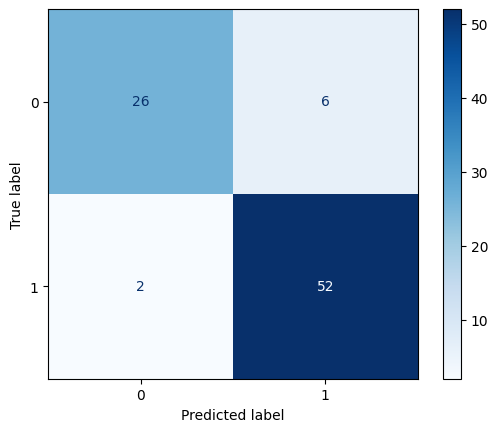

In [186]:
accuracy_rf = accuracy_score(t_test, t_test_pred)
precision_rf = precision_score(t_test, t_test_pred)
recall_rf = recall_score(t_test, t_test_pred)
f1_rf = f1_score(t_test, t_test_pred)
conf_matrix_rf = confusion_matrix(t_test, t_test_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf)

disp_rf.plot(cmap=plt.cm.Blues)

print("Final Test Set Performance (Benign Class):")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")

## Decision Tree vs Random Forest Model Comparison

Comparing the best Decision Tree and Random Forest models with their respective 

In [ ]:
def get_metrics_df(name, accuracy, precision, recall, f1_score):
    return pd.DataFrame({
        "Model": [name],
        "Accuracy": [accuracy],
        "Precision": [precision],
        "Recall": [recall],
        "F1 Score": [f1_score]
        })

df_results_dt = get_metrics_df("Decision Tree", accuracy_dt, precision_dt, recall_dt, f1_dt)  
df_results_rf = get_metrics_df("Random Forest", accuracy_rf, precision_rf, recall_rf, f1_rf)

df_comparison = pd.concat([df_results_dt, df_results_rf], ignore_index=True)

print("Model Comparison on Test Set:")
print("Metrics are for the 'Benign' class (1).")

df_comparison

Model Comparison on Test Set:
Metrics are for the 'Benign' class (1).


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.883721,0.892857,0.925926,0.909091
1,Random Forest,0.906977,0.896552,0.962963,0.928571


### Bias vs Variance Comparison

As shown in the comparison table, the Random Forest (90.70%) outperformed the single Decision Tree (88.37%). This improvement can be analyzed through the **Bias-Variance Decomposition** framework.

#### 1. Variance Reduction

* **Single Decision Trees** are known to have **High Variance**. They are sensitive to specific details in the training data. This explains why the single decision tree had 99% training accuracy but dropped to 88% on the test set, which is a sign of overfitting.

* **Random Forests** reduce this variance through **Bagging** (Bootstrap Sampling). By training T trees on random bootstrap samples and averaging their predictions:
    The ensemble "smooths out" the decision boundaries, reducing the variability of the prediction without significantly increasing bias.

#### 2. Bias Analysis

* Both the Decision Tree and the Random Forest exhibit **Low Bias**. They are both capable of capturing complex, non-linear relationships in the data.

* Bagging generally **does not change the bias** (the averaged prediction has the same expectation as the individual trees). Therefore, the improvement in test accuracy is almost entirely attributable to the reduction in variance.

The Random Forest improved upon standard bagging by using **feature randomness**. This ensures that the individual trees in the random forest are less correlated with each other which further minimizes the variance of the ensemble prediction.

The Random Forest successfully reduced the high variance of the single Decision Tree while maintaining low bias, resulting in better generalization to the unseen Test Set.